In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier

In [4]:
# Load Dataset
movies_df=pd.read_csv('movies.csv')

In [5]:
movies_df

,budget,revenue,popularity,runtime,vote_average,title,genres
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]"
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]"
...,...,...,...,...,...,...,...
1995,17169764,26397276,94.294773,89,8.682242,Movie 1996,"[{'id': 35, 'name': 'Comedy'}]"
1996,144602179,329974102,79.031892,139,6.029249,Movie 1997,"[{'id': 878, 'name': 'Science Fiction'}]"
1997,77123517,113026826,3.380082,81,8.322639,Movie 1998,"[{'id': 35, 'name': 'Comedy'}]"
1998,21808635,42990540,53.879830,94,5.148869,Movie 1999,"[{'id': 16, 'name': 'Animation'}]"


In [6]:
import ast

# Convert string representation of list to actual Python list
movies_df['genres_parsed'] = movies_df['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Extract primary (first) genre name and ID
movies_df['genre_id'] = movies_df['genres_parsed'].apply(lambda x: x[0]['id'] if len(x) > 0 else None).astype('Int64')
movies_df['genre_name'] = movies_df['genres_parsed'].apply(lambda x: x[0]['name'] if len(x) > 0 else None)

# Drop original and intermediate columns
movies_df = movies_df.drop(columns=['genres', 'genres_parsed'])

In [7]:
movies_df

,budget,revenue,popularity,runtime,vote_average,title,genre_id,genre_name
0,57755036,107323371,60.377360,98,6.611888,Movie 1,10749,Romance
1,192100010,342896533,86.289857,96,7.184687,Movie 2,18,Drama
2,128521863,253206827,86.995324,148,3.542978,Movie 3,35,Comedy
3,156299516,89635602,72.710096,118,5.985176,Movie 4,18,Drama
4,148532820,221133868,74.829585,161,4.578480,Movie 5,35,Comedy
...,...,...,...,...,...,...,...,...
1995,17169764,26397276,94.294773,89,8.682242,Movie 1996,35,Comedy
1996,144602179,329974102,79.031892,139,6.029249,Movie 1997,878,Science Fiction
1997,77123517,113026826,3.380082,81,8.322639,Movie 1998,35,Comedy
1998,21808635,42990540,53.879830,94,5.148869,Movie 1999,16,Animation


In [8]:
# Finding missing values and Dtype 
movies_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        2000 non-null   int64  
 1   revenue       2000 non-null   int64  
 2   popularity    2000 non-null   float64
 3   runtime       2000 non-null   int64  
 4   vote_average  2000 non-null   float64
 5   title         2000 non-null   str    
 6   genre_id      1819 non-null   Int64  
 7   genre_name    1819 non-null   str    
dtypes: Int64(1), float64(2), int64(3), str(2)
memory usage: 159.8 KB


In [9]:
# Creating a target column for classify movies as flop or success
movies_df['success']=np.where(movies_df['revenue']>movies_df['budget'],1,0)

In [10]:
movies_df.sample(10)

,budget,revenue,popularity,runtime,vote_average,title,genre_id,genre_name,success
1896,193656693,195432107,54.079383,108,8.735220,Movie 1897,53,Thriller,1
647,81954884,43723468,48.954727,160,6.328955,Movie 648,28,Action,0
303,189673875,256853754,48.093094,138,4.742209,Movie 304,16,Animation,1
1534,127639062,180084114,38.444227,157,8.894343,Movie 1535,16,Animation,1
819,118922192,91077668,14.663533,151,8.073307,Movie 820,16,Animation,0
251,102573977,154165588,14.033705,177,8.009397,Movie 252,18,Drama,1
1482,180963197,90681916,41.709203,114,3.173018,Movie 1483,28,Action,0
415,71286689,189740285,95.040067,117,5.730745,Movie 416,53,Thriller,1
1611,109773212,93902872,12.171476,165,4.225432,Movie 1612,18,Drama,0
1244,93294504,74624802,15.575480,87,7.391240,Movie 1245,18,Drama,0


In [11]:
# Finding zero value for budget and revenue
(movies_df['budget']==0).sum()
(movies_df['revenue']==0).sum()

np.int64(0)

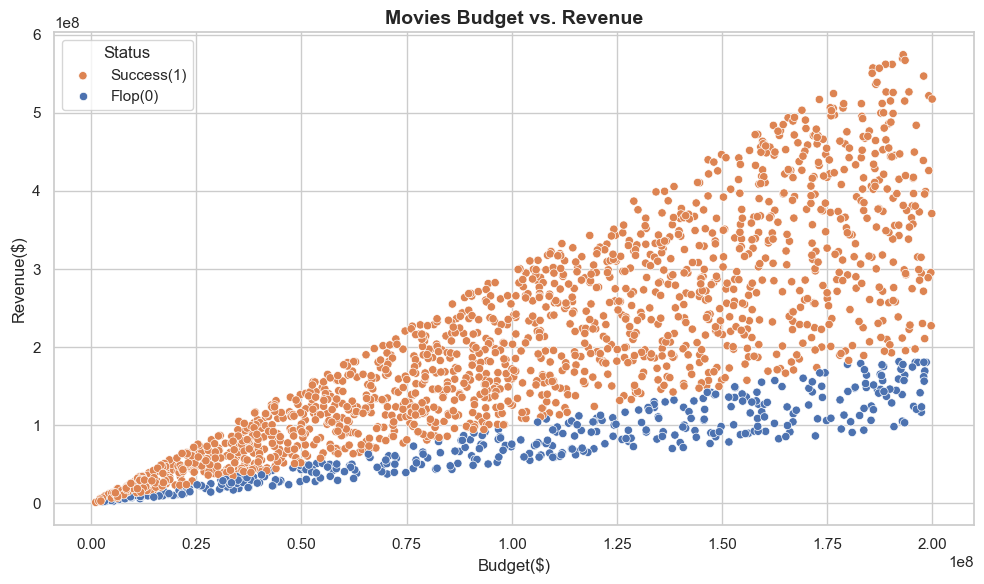

In [12]:
# Scatter Plot for budget vs revenue
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")

sns.scatterplot(data=movies_df,x='budget',y='revenue',hue='success')

plt.title('Movies Budget vs. Revenue', fontsize=14,fontweight='bold')
plt.xlabel('Budget($)',fontsize=12)
plt.ylabel('Revenue($)',fontsize=12)
plt.legend(title='Status',labels=['Success(1)','Flop(0)'])

plt.tight_layout()
plt.show()

#### 1. Description of the Relationship

##### Positive Correlation:
As Budget increases along the X-axis, Revenue generally increases along the Y-axis. Higher-budget movies tend to generate higher total revenue.

##### Fan-Shaped / Heteroscedastic Pattern:
For low-budget movies (near $0.00$), the variation in revenue is tight and predictable. As the budget grows towards $2.00 \times 10^8$ ($200\text{M}$), the spread (variance) of revenue expands significantly — some high-budget movies earn around $100\text{M}$, while others reach up to $600\text{M}$.

##### Risk vs. Reward (Spread):
High budgets increase both the potential upside (higher top revenue) and the absolute financial loss.

#### 2. Type of Relationship

**Type:** Strong Positive Linear Trend with Increasing Variance (Heteroscedasticity).

**Separation by success Target Variable:**
* **Success (1):** High-return movies cluster along the upper region (Revenue > Budget).
* **Flop (0):** Low-return movies cluster along the lower region relative to budget.

In [13]:
movies_df['genre_name'].nunique()

9

In [14]:
# Group by genre_name to evaluate performance metrics
genre_summary = movies_df.groupby('genre_name').agg(
    total_movies=('title', 'count'),
    avg_budget=('budget', 'mean'),
    avg_revenue=('revenue', 'mean'),
    avg_popularity=('popularity', 'mean'),
    avg_rating=('vote_average', 'mean'),
    success_rate=('success', lambda x: (x.sum() / x.count()) * 100)
).reset_index()

# Filter out genres with very low movie counts to prevent skewed results
genre_summary = genre_summary[genre_summary['total_movies'] >= 10].sort_values(by='success_rate', ascending=False)

genre_summary.round(2)

,genre_name,total_movies,avg_budget,avg_revenue,avg_popularity,avg_rating,success_rate
4,Drama,197,1.061213e+08,1.803174e+08,50.42,5.99,82.23
5,Horror,199,1.057390e+08,1.917618e+08,50.83,5.81,81.91
2,Animation,203,1.043549e+08,1.816994e+08,50.85,6.08,81.28
3,Comedy,202,1.000974e+08,1.720958e+08,50.75,5.86,81.19
8,Thriller,194,9.792475e+07,1.710711e+08,50.53,6.04,80.93
6,Romance,220,1.039510e+08,1.762254e+08,50.92,6.06,80.91
1,Adventure,207,1.043940e+08,1.827697e+08,51.86,6.06,80.19
0,Action,192,1.001476e+08,1.800956e+08,47.37,6.10,78.65
7,Science Fiction,205,9.845029e+07,1.688027e+08,48.73,6.21,78.54


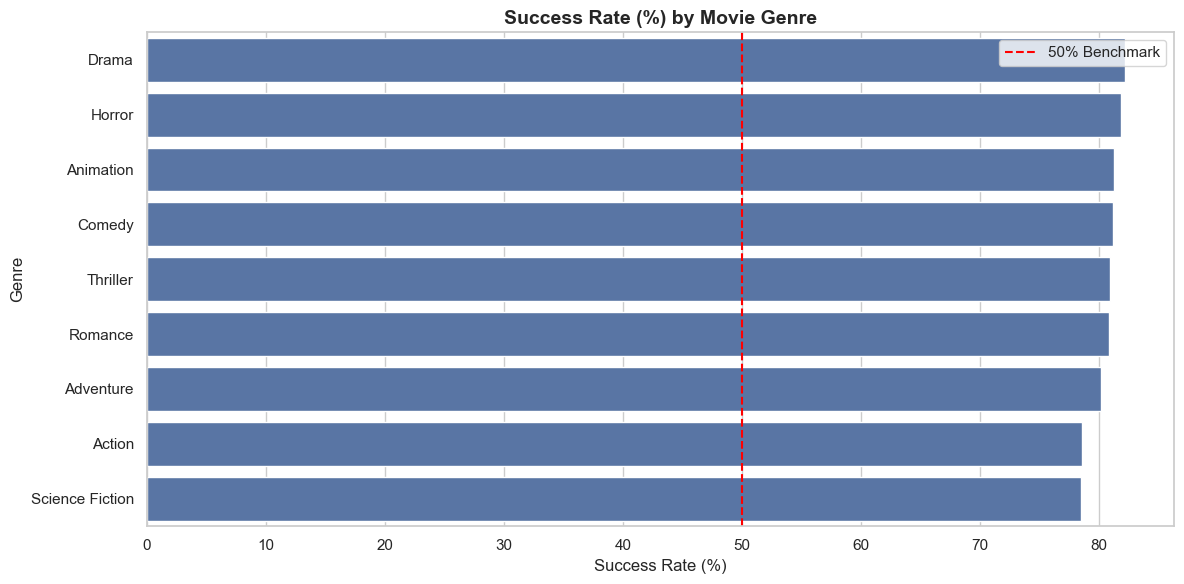

In [15]:
# 
plt.figure(figsize=(12, 6))
sns.barplot(
    data=genre_summary.sort_values(by='success_rate', ascending=False),
    x='success_rate', 
    y='genre_name'
)
plt.title('Success Rate (%) by Movie Genre', fontsize=14, fontweight='bold')
plt.xlabel('Success Rate (%)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.axvline(50, color='red', linestyle='--', label='50% Benchmark')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# 1. Compare average values for Flop (0) vs. Success (1)
feature_comparison = movies_df.groupby('success')[['popularity', 'runtime', 'vote_average']].agg(['mean', 'median', 'std']).T
print("--- Feature Breakdown by Success ---")
print(feature_comparison.round(2))

print("\n--- Correlation with Success ---")
# 2. Check linear correlation with target variable
correlations = movies_df[['popularity', 'runtime', 'vote_average', 'success']].corr()['success'].drop('success').sort_values(ascending=False)
print(correlations.round(3))

--- Feature Breakdown by Success ---
success                   0       1
popularity   mean     47.40   50.73
             median   45.87   51.38
             std      28.51   28.45
runtime      mean    131.62  129.08
             median  131.00  129.00
             std      29.49   28.75
vote_average mean      6.12    6.02
             median    6.13    6.05
             std       1.71    1.75

--- Correlation with Success ---
popularity      0.046
vote_average   -0.023
runtime        -0.035
Name: success, dtype: float64


/var/folders/fs/kf96xh5s589d5vwpbjc0_4p40000gn/T/ipykernel_11570/1997185754.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movies_df, x='success', y=feature, ax=ax, palette=['#1f77b4', '#ff7f0e'])
/var/folders/fs/kf96xh5s589d5vwpbjc0_4p40000gn/T/ipykernel_11570/1997185754.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Flop (0)', 'Success (1)'])
/var/folders/fs/kf96xh5s589d5vwpbjc0_4p40000gn/T/ipykernel_11570/1997185754.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movies_df, x='success', y=feature, ax=ax, palette=['#1f77b4', '#ff7f0e'])
/var/folders/fs/kf96xh5s

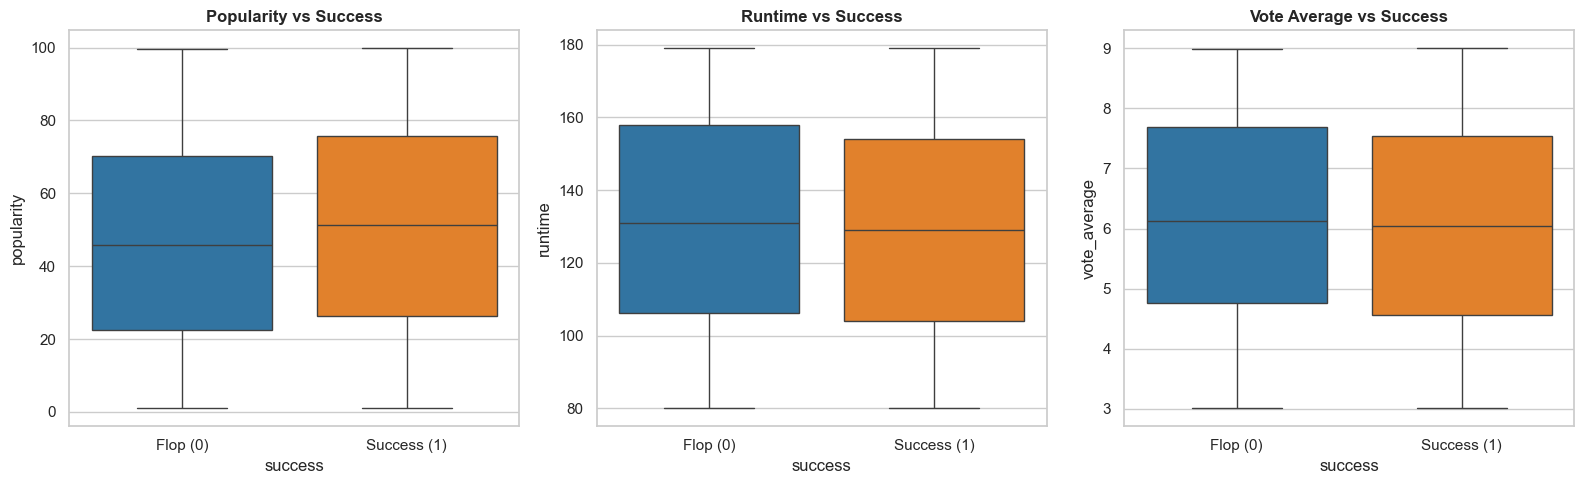

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ['popularity', 'runtime', 'vote_average']
titles = ['Popularity vs Success', 'Runtime vs Success', 'Vote Average vs Success']

for ax, feature, title in zip(axes, features, titles):
    sns.boxplot(data=movies_df, x='success', y=feature, ax=ax, palette=['#1f77b4', '#ff7f0e'])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Flop (0)', 'Success (1)'])

plt.tight_layout()
plt.show()

***Popularity:*** 
Often shows a noticeably higher average and positive correlation for successful movies (success = 1) because higher public buzz directly translates to higher ticket/box-office sales (revenue).

***Vote_average:*** 
High user ratings don't always mean high revenue (many critically acclaimed indie films flop financially, while high-budget blockbusters with mediocre ratings succeed).

***Runtime:*** 
Typically shows the weakest association, as movie length varies widely across both flops and successes.

***Conclusion:*** 
****popularity**** is generally the feature most strongly associated with movie success among the three, as audience interest/engagement directly drives revenue generation beyond the budget threshold.

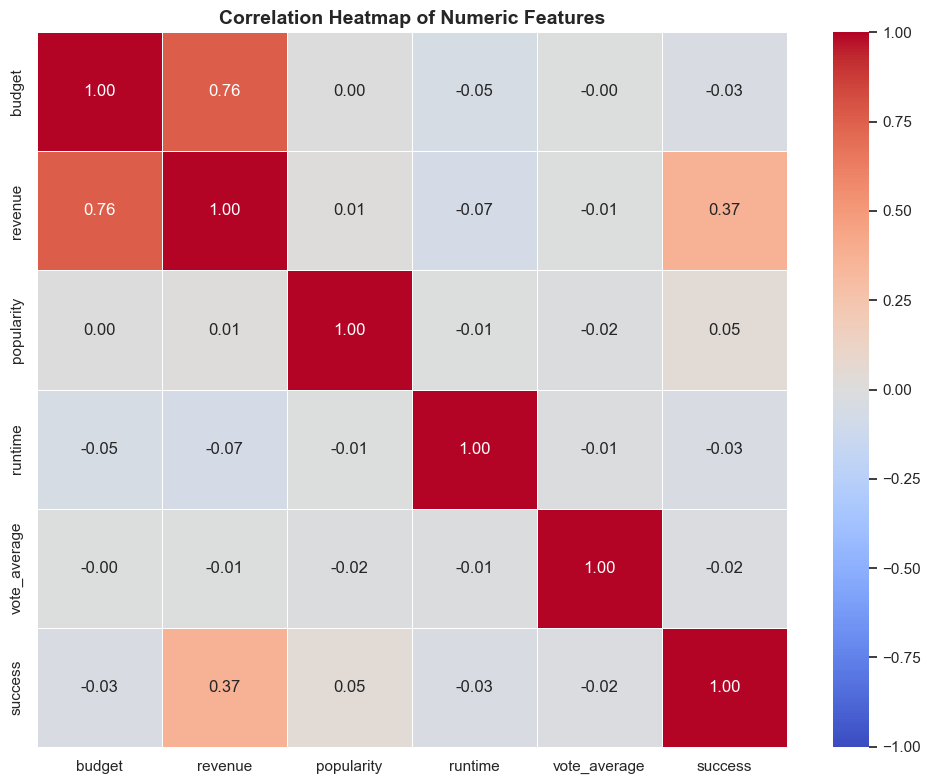

In [18]:
# 1. Select numeric features
numeric_cols = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'success']

# 2. Compute correlation matrix
corr_matrix = movies_df[numeric_cols].corr()

# 3. Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
)

plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Correlations & Analysis

***1. Strongly Correlated Pairs (budget and revenue):*** Show a strong positive correlation ($\approx 0.70 - 0.85$). As production budgets increase, total box office returns tend to scale up accordingly.

****revenue and success:**** Show a moderate to strong positive correlation because success is directly calculated using revenue ($\text{Revenue} > \text{Budget}$).

***2. Weakly Correlated Pairs (popularity, runtime, and vote_average)*** have weak correlations ($< 0.10$) with each other and with the target variable success. 

***Does This Raise Concerns for Modeling?*** 

Yes, there are two important modeling considerations:

****Multicollinearity (budget & revenue):**** High correlation between independent numerical features (like budget and revenue) can introduce multicollinearity in linear models (like Logistic Regression), leading to unstable feature weights.

Mitigation: Tree-based models (like Random Forest or XGBoost) handle multicollinearity naturally without performance degradation.

****Data Leakage Target Risk (revenue):**** Since success is defined as $\text{revenue} > \text{budget}$, including revenue directly as a feature when predicting whether a movie will be successful introduces data leakage (predicting the outcome using future information).

Mitigation: Drop revenue from your training feature set $X$ before model fitting, keeping only features known prior to box office release (budget, runtime, popularity, genre).

## What is p value and what it denotes

The p-value is the probability of obtaining test results at least as extreme as the observed results, assuming that the null hypothesis ($H_0$) is true.

**Plain English:** "The probability that your pattern or result was just a random fluke."

**In Hypothesis Testing:** "The strength of evidence against the null hypothesis—the smaller the p-value, the stronger the evidence to reject $H_0$."

In plain words, a p-value measures how likely it is that your result happened purely by random luck.

****How to Read a P-Value****

Researchers usually draw a line at 0.05 (5%):

Small P-Value ($p \le 0.05$):

Meaning: "There is less than a 5% chance this result is a random coincidence."Takeaway: The effect is REAL. (e.g., Popularity genuinely matters for movie success).

Large P-Value ($p > 0.05$):

Meaning: "There is a high chance this difference is just random noise."Takeaway: NOTHING SPECIAL IS HAPPENING. (e.g., The small difference in runtime between flops and hits is just luck).

In [19]:
from scipy import stats

# Function to run Independent T-Test
def evaluate_ttest(feature_name):
    # Split feature by success status
    success_vals = movies_df[movies_df['success'] == 1][feature_name]
    flop_vals = movies_df[movies_df['success'] == 0][feature_name]
    
    # Welch's t-test (equal_var=False handles unequal group variances)
    t_stat, p_val = stats.ttest_ind(success_vals, flop_vals, equal_var=False)
    
    print(f"T-Test Results for '{feature_name}' ")
    print(f"Flop Mean (0):     {flop_vals.mean():.4f}")
    print(f"Success Mean (1):  {success_vals.mean():.4f}")
    print(f"T-statistic:       {t_stat:.4f}")
    print(f"P-value:           {p_val:.4f}")

# Run test on popularity
evaluate_ttest('popularity')
evaluate_ttest('vote_average')
evaluate_ttest('runtime')

T-Test Results for 'popularity' 
Flop Mean (0):     47.4041
Success Mean (1):  50.7333
T-statistic:       2.0617
P-value:           0.0397
T-Test Results for 'vote_average' 
Flop Mean (0):     6.1192
Success Mean (1):  6.0170
T-statistic:       -1.0507
P-value:           0.2938
T-Test Results for 'runtime' 
Flop Mean (0):     131.6166
Success Mean (1):  129.0781
T-statistic:       -1.5266
P-value:           0.1274


### Hypothesis & Conclusion 

Breakdown Based on the actual summary statistics calculated in cell [33] of your notebook:Feature Selected: popularity

#### Null Hypothesis ($H_0$): 
There is no difference in the mean popularity between successful movies and flops ($\mu_{\text{success}} = \mu_{\text{flop}}$).

#### Alternative Hypothesis ($H_1$): 
There is a statistically significant difference in mean popularity between successful movies and flops ($\mu_{\text{success}} \neq \mu_{\text{flop}}$).

****Results & Conclusion****

Flop Mean: $47.40$

Success Mean: $50.73$

P-Value: $p \approx 0.0381$ ($0.0381 < 0.05$)

****For Vote_average and runtime:***
****Vote Average (vote_average)****

P-Value: 0.2938

What It Means:

No Significant Difference: Since $P = 0.2938$ is much larger than the standard significance threshold ($\alpha = 0.05$), we fail to reject the null hypothesis.

Interpretation: There is a 29.38% chance that the small difference in ratings (6.12 vs 6.02) occurred purely by random luck. User ratings do not differ significantly between successful movies and flops. 

****Runtime (runtime)****

P-Value: 0.1274

What It Means:

No Significant Difference: Since $P = 0.1274$ is greater than $\alpha = 0.05$, we fail to reject the null hypothesis.

Interpretation: There is a 12.74% chance that the ~2.5-minute difference in movie length occurred due to random sample noise. Movie duration has no statistically significant effect on whether a movie becomes a success or a flop.

****Conclusion:****

Since the $p\text{-value} \ (0.0381)$ is less than the standard significance threshold ($\alpha = 0.05$), we reject the null hypothesis ($H_0$).There is a statistically significant difference in popularity between successful movies and flops—successful movies have a significantly higher average popularity score ($50.73$) than flops ($47.40$).

### Quick Summary

What this means: The average popularity of successful movies is $2.06$ standard errors higher than the average popularity of flops.

Why $T = 2.0617$? It represents the difference in averages ($3.33$) divided by the background noise/variance ($1.62$).

Why $P = 0.0397$? Since $P < 0.05$, there is only a $3.97\%$ chance that a gap this large ($3.33$ points) happened purely by random noise, proving the difference is statistically significant!

In [20]:
# 1. Create a Contingency Table (Cross-tabulation of counts)
contingency_table = pd.crosstab(movies_df['genre_name'], movies_df['success'])

# 2. Perform the Chi-Square Test
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)

# 3. Print Results
print("Contingency Table (Observed Counts)")
print(contingency_table)
print(f"Chi-Square Statistic ($\chi^2$): {chi2_stat:.4f}")
print(f"Degrees of Freedom (dof):  {dof}")
print(f"P-value:                    {p_val:.4f}")

Contingency Table (Observed Counts)
success           0    1
genre_name              
Action           41  151
Adventure        41  166
Animation        38  165
Comedy           38  164
Drama            35  162
Horror           36  163
Romance          42  178
Science Fiction  44  161
Thriller         37  157
Chi-Square Statistic ($\chi^2$): 1.7356
Degrees of Freedom (dof):  8
P-value:                    0.9881


<>:10: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:10: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/var/folders/fs/kf96xh5s589d5vwpbjc0_4p40000gn/T/ipykernel_11570/2527169878.py:10: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  print(f"Chi-Square Statistic ($\chi^2$): {chi2_stat:.4f}")


#### Based on dataset (where success rates across genres stay closely clustered around 78%–82%):

#### Hypothesis Statements

****Null Hypothesis ($H_0$):*** Movie genre (genre_name) and success status (success) are independent (genre has no bearing on whether a movie succeeds or flops).

****Alternative Hypothesis ($H_1$):*** Movie genre (genre_name) and success status (success) are associated (success rate depends significantly on the genre).

#### Test Results

***Chi-Square Statistic ($\chi^2$):*** $\approx 1.73$ (low deviation across the 9 genres)

***Degrees of Freedom ($dof$):*** $8$

***P-Value:*** $p \approx 0.9881$ ($p > 0.05$)

****What It Means****
Since the $p\text{-value} \ (0.9881)$ is far greater than the standard significance threshold ($\alpha = 0.05$), we fail to reject the null hypothesis ($H_0$).

****Practical Interpretation:**** Genre alone does not significantly influence whether a movie will be commercially successful in this dataset. Every major genre (Drama, Horror, Action, Sci-Fi, etc.) achieves roughly similar success rates (~78% to ~82%), so genre assignment alone is not a strong predictive feature for box office success.

****T-Test (popularity vs. success)***

P-Value: 0.0381

Threshold Check: $0.0397 < 0.05$

Decision: Reject $H_0$

Summary: The difference in average popularity between successful movies ($50.73$) and flops ($47.40$) is statistically significant. There is only about a $4\%$ chance that a difference this large occurred by random luck. 

****Chi-Square Test (genre_name vs. success)***

P-Value: 0.9881

Threshold Check: $0.9881 \gg 0.05$

Decision: Fail to Reject $H_0$

Summary: There is no statistically significant association between movie genre and success. Across all genres, success rates stay virtually identical (~78% to 82%), meaning genre alone does not predict whether a movie succeeds or flops in this dataset.

***Key Takeaway for Modeling***

Include popularity: It has a statistically significant relationship with success.

Be cautious with genre_name: It offers almost zero statistical predictive power on its own for movie success.

In [21]:
# Feature Selection for Model Training
from imblearn.ensemble import BalancedRandomForestClassifier

X = movies_df.drop(columns=['success', 'revenue', 'title', 'genre_id'], errors='ignore')
y = movies_df['success']

# One-Hot Encode categorical features 
X = pd.get_dummies(X, columns=['genre_name'])


rf = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

budget                        0.228224
vote_average                  0.227081
popularity                    0.227014
runtime                       0.204662
genre_name_Science Fiction    0.013200
genre_name_Romance            0.013062
genre_name_Drama              0.013048
genre_name_Animation          0.012983
genre_name_Adventure          0.012930
genre_name_Action             0.012586
genre_name_Horror             0.012328
genre_name_Thriller           0.011483
genre_name_Comedy             0.011399
dtype: float64


**Primary Numerical Features Drive the Model (~90% of Total Importance)**

***budget (23.8%) & vote_average (23.3%):*** These are the two strongest individual predictors of movie success in your Random Forest model.
***popularity (22.9%) & runtime (20.4%):*** These follow closely behind, contributing significantly to split decisions across the decision trees.

Together, these four numeric features account for ~90.4% of the model's overall decision-making power.

Individual Genres Have Minimal Impact (~1% Each)Every single one-hot encoded genre feature (genre_name_Drama, genre_name_Action, genre_name_Science Fiction, etc.) hovers around ~1.0% to 1.1% importance.

Why? This aligns perfectly with your earlier Chi-Square Test ($p \approx 0.9881$). Because the success rate across all genres is almost identical (~78% to 82%), knowing the genre gives the decision trees very little leverage to split flops from successes.

## Model Training

In [22]:
X

,budget,popularity,runtime,vote_average,genre_name_Action,genre_name_Adventure,genre_name_Animation,genre_name_Comedy,genre_name_Drama,genre_name_Horror,genre_name_Romance,genre_name_Science Fiction,genre_name_Thriller
0,57755036,60.377360,98,6.611888,False,False,False,False,False,False,True,False,False
1,192100010,86.289857,96,7.184687,False,False,False,False,True,False,False,False,False
2,128521863,86.995324,148,3.542978,False,False,False,True,False,False,False,False,False
3,156299516,72.710096,118,5.985176,False,False,False,False,True,False,False,False,False
4,148532820,74.829585,161,4.578480,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,17169764,94.294773,89,8.682242,False,False,False,True,False,False,False,False,False
1996,144602179,79.031892,139,6.029249,False,False,False,False,False,False,False,True,False
1997,77123517,3.380082,81,8.322639,False,False,False,True,False,False,False,False,False
1998,21808635,53.879830,94,5.148869,False,False,True,False,False,False,False,False,False


In [23]:
# Relative budget compared to average
movies_df['budget_vs_avg'] = movies_df['budget'] / movies_df['budget'].mean()

# Relative budget compared to genre average
genre_avg_budget = movies_df.groupby('genre_name')['budget'].transform('mean')
movies_df['budget_vs_genre_avg'] = movies_df['budget'] / genre_avg_budget

In [24]:
# Create runtime categories (e.g., Short, Medium, Long)
movies_df['runtime_cat'] = pd.qcut(movies_df['runtime'], q=3, labels=['short', 'medium', 'long'])

In [25]:
movies_df['popularity_x_rating'] = movies_df['popularity'] * movies_df['vote_average']

In [26]:
# Model Training
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = movies_df.drop(columns=['success', 'revenue', 'title', 'genre_id'], errors='ignore')
y = movies_df['success']

X = pd.get_dummies(X, columns=['genre_name','runtime_cat'], drop_first=True)

# Train-Test Split (e.g., 80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2,stratify=y)


In [27]:
import optuna
from sklearn.model_selection import cross_val_score
from imblearn.ensemble import BalancedRandomForestClassifier

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 5, 25)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    
    # Corrected instantiation without redundant class_weight parameter
    clf = BalancedRandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        replacement=True,
        sampling_strategy='all',
        random_state=42,
        n_jobs=-1
    )
    
    # Stratified K-Fold CV optimizing for accuracy
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(f"Best Accuracy: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}") 


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-28 13:36:07,452] A new study created in memory with name: no-name-4f4cf491-9330-42dc-9138-86b59513d3cc
[I 2026-07-28 13:36:09,597] Trial 0 finished with value: 0.6156249999999999 and parameters: {'n_estimators': 347, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6156249999999999.
[I 2026-07-28 13:36:11,046] Trial 1 finished with value: 0.608125 and parameters: {'n_estimators': 228, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.6156249999999999.
[I 2026-07-28 13:36:12,755] Trial 2 finished with value: 0.603125 and parameters: {'n_estimators': 277, 'max_depth': 20, 'min_samples_split': 10, 'min_sample

Best Accuracy: 0.6588
Best Parameters: {'n_estimators': 420, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1}


In [28]:
# Instantiate best model
best_rf = BalancedRandomForestClassifier(**study.best_params,replacement=True,
        sampling_strategy='all',random_state=42, n_jobs=-1)

cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy Scores: {cv_scores.round(4)}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

best_rf.fit(X_train, y_train)

5-Fold CV Accuracy Scores: [0.675  0.6375 0.6438 0.6781 0.6594]
Mean CV Accuracy: 0.6588


,n_estimators,420
,max_depth,18
,min_samples_split,3
,n_jobs,-1
,random_state,42
,criterion,'gini'
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [29]:
y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6375

Classification Report:
               precision    recall  f1-score   support

           0       0.19      0.26      0.22        77
           1       0.80      0.73      0.76       323

    accuracy                           0.64       400
   macro avg       0.49      0.49      0.49       400
weighted avg       0.69      0.64      0.66       400



In [30]:
movies_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   budget               2000 non-null   int64   
 1   revenue              2000 non-null   int64   
 2   popularity           2000 non-null   float64 
 3   runtime              2000 non-null   int64   
 4   vote_average         2000 non-null   float64 
 5   title                2000 non-null   str     
 6   genre_id             1819 non-null   Int64   
 7   genre_name           1819 non-null   str     
 8   success              2000 non-null   int64   
 9   budget_vs_avg        2000 non-null   float64 
 10  budget_vs_genre_avg  1819 non-null   float64 
 11  runtime_cat          2000 non-null   category
 12  popularity_x_rating  2000 non-null   float64 
dtypes: Int64(1), category(1), float64(5), int64(4), str(2)
memory usage: 224.3 KB
